# Notebook 01 — VQC Circuits: Definition & Visualization

**Project:** Quantum Attention Mechanism Benchmark  
**Author:** Sarah Assou  
**Goal:** Define and visualize three variational quantum circuit (VQC) architectures that will be used as attention layers in subsequent notebooks.

---

## What this notebook covers

1. **Setup** — install and import everything needed
2. **Background** — what is a VQC and why use it as an attention layer?
3. **Circuit 1** — Strongly Entangling Layers
4. **Circuit 2** — IQP Embedding (data re-uploading style)
5. **Circuit 3** — Hardware-Efficient Ansatz
6. **Classical Baseline** — standard softmax attention (for comparison)
7. **Parameter count comparison** — how many trainable parameters does each circuit have?
8. **Output distribution** — visualize what each circuit outputs on random inputs

---

## Cell 1 — Install Dependencies

In [1]:
!pip install pennylane pennylane-lightning matplotlib numpy torch --quiet
print("✅ All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.2 MB/s eta 0:00:00
✅ All packages installed.


## Cell 2 — Imports & Version Check

In [2]:
import pennylane as qml
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

print(f"PennyLane version : {qml.__version__}")
print(f"PyTorch version   : {torch.__version__}")
print(f"NumPy version     : {np.__version__}")
print("\n✅ All imports successful.")

PennyLane version : 0.44.1
PyTorch version   : 2.10.0+cu128
NumPy version     : 2.0.2

✅ All imports successful.


---

## Background: VQCs as Attention Layers

### Standard attention (classical)

In a classical transformer, the attention mechanism computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

where Q (queries), K (keys), V (values) are learned linear projections of the input.

### VQC attention (quantum hybrid)

Instead of computing attention weights with classical dot products, we encode the input into a quantum circuit and measure the output as attention weights:

$$\text{Attention}_{\text{VQC}}(x) = \langle 0 | U^\dagger(\theta, x) \hat{O} \, U(\theta, x) | 0 \rangle$$

Where:
- $U(\theta, x)$ is the parameterized quantum circuit (ansatz)
- $\theta$ are trainable parameters (like weights in a neural network)
- $x$ is the classical input (encoded into the circuit)
- $\hat{O}$ is an observable we measure (e.g., Pauli-Z on each qubit)

The output is a vector of expectation values ∈ [-1, 1] which we use as attention scores.

### Why study different VQC architectures?

Not all VQCs are equal. They differ in:
- **Expressibility** — how many different functions they can approximate
- **Entanglement** — how strongly qubits interact with each other
- **Trainability** — whether gradients vanish during training (barren plateaus)

This project benchmarks 3 architectures to find the best fit for attention computation.

---

## Cell 3 — Global Configuration

In [3]:
# ── Global hyperparameters ──────────────────────────────────────────────────
N_QUBITS = 4      # Number of qubits in each circuit
N_LAYERS = 2      # Number of repetition layers in each circuit
INPUT_DIM = 4     # Dimension of classical input vector (must equal N_QUBITS for angle encoding)

# Device: lightning.qubit is faster than default.qubit for simulation
dev = qml.device("lightning.qubit", wires=N_QUBITS)

print(f"Device  : {dev.name}")
print(f"Qubits  : {N_QUBITS}")
print(f"Layers  : {N_LAYERS}")
print(f"Input   : R^{INPUT_DIM} → {N_QUBITS}-qubit Hilbert space")

Device  : lightning.qubit
Qubits  : 4
Layers  : 2
Input   : R^4 → 4-qubit Hilbert space


---

## Circuit 1 — Strongly Entangling Layers (SEL)

### What it is
SEL is a general-purpose ansatz designed for high expressibility. Each layer applies:
1. A rotation gate (Rot = Rz · Ry · Rz) to each qubit — 3 parameters per qubit
2. CNOT entangling gates connecting every qubit to every other qubit

### Parameter count
`n_layers × n_qubits × 3` — for our config: `2 × 4 × 3 = 24 parameters`

In [4]:
# ── Circuit 1: Strongly Entangling Layers ──────────────────────────────────

def sel_circuit_raw(inputs, weights):
    """
    Strongly Entangling Layers circuit (no QNode decorator).
    Used internally by the QNode wrapper below.

    Args:
        inputs  : 1D array of shape (N_QUBITS,) — classical input to encode
        weights : 3D array of shape (N_LAYERS, N_QUBITS, 3) — trainable parameters
    """
    # Step 1: Encode classical input as rotation angles on each qubit
    # RY(x_i) rotates qubit i by angle x_i around the Y-axis
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')

    # Step 2: Apply strongly entangling layers
    # Each layer = Rot gates (Rz·Ry·Rz) + ring of CNOT entanglers
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Step 3: Measure Pauli-Z expectation value on each qubit
    # Output: vector of N_QUBITS values in [-1, 1]
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


@qml.qnode(dev, interface='torch')
def sel_circuit(inputs, weights):
    return sel_circuit_raw(inputs, weights)


# Parameter shape for SEL
sel_weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=N_QUBITS)
sel_weights_init = torch.tensor(np.random.uniform(0, 2*np.pi, sel_weight_shape), dtype=torch.float32)

# Test with a random input
test_input = torch.tensor(np.random.uniform(0, np.pi, N_QUBITS), dtype=torch.float32)
sel_output = sel_circuit(test_input, sel_weights_init)

print("Circuit 1: Strongly Entangling Layers")
print(f"  Weight shape     : {sel_weight_shape}")
print(f"  Total parameters : {np.prod(sel_weight_shape)}")
print(f"  Test input       : {test_input.numpy().round(3)}")
print(f"  Output (expvals) : {[round(float(v), 4) for v in sel_output]}")
print(f"  Output range     : [-1, 1] ✓" if all(-1 <= float(v) <= 1 for v in sel_output) else "  ⚠️ Output out of range")

Circuit 1: Strongly Entangling Layers
  Weight shape     : (2, 4, 3)
  Total parameters : 24
  Test input       : [0.285 1.943 1.202 3.089]
  Output (expvals) : [-0.1107, -0.1028, 0.2634, 0.1936]
  Output range     : [-1, 1] ✓


In [5]:
# Visualize the SEL circuit
print("Circuit 1 diagram (SEL):")
print(qml.draw(sel_circuit)(test_input, sel_weights_init))

Circuit 1 diagram (SEL):
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
tensor([0.2846, 1.9427, 1.2015, 3.0889])
M1 = 
tensor([[[5.0048e+00, 1.1526e+00, 4.8989e+00],
         [3.7501e+00, 2.8012e+00, 6.2816e-01],
         [2.8855e+00, 2.0968e+00, 8.9766e-01],
         [4.0897e+00, 3.5444e-01, 4.5365e+00]],

        [[5.8971e+00, 4.8931e-03, 6.2342e+00],
         [3.8798e+00, 3.8431e+00, 4.4399e-02],
         [1.4491e-01, 3.2973e+00, 2.5124e+00],
         [2.9321e-01, 6.1183e+00, 1.4625e+00]]])


---

## Circuit 2 — IQP-Style with Data Re-uploading

### What it is
IQP (Instantaneous Quantum Polynomial) circuits interleave data encoding with trainable rotations across multiple layers. The key idea is **data re-uploading** — the input is encoded *at every layer*, not just once. This lets the circuit learn richer input-dependent functions.

### Parameter count
`n_layers × n_qubits × 2` — for our config: `2 × 4 × 2 = 16 parameters`

In [6]:
# ── Circuit 2: IQP-Style with Data Re-uploading ────────────────────────────

@qml.qnode(dev, interface='torch')
def iqp_circuit(inputs, weights):
    """
    IQP-style circuit with data re-uploading.

    Args:
        inputs  : 1D array of shape (N_QUBITS,)
        weights : 3D array of shape (N_LAYERS, N_QUBITS, 2)
                  weights[l, i, 0] = RZ angle for qubit i at layer l
                  weights[l, i, 1] = RY angle for qubit i at layer l
    """
    for layer in range(N_LAYERS):

        # ── Data encoding: re-upload input at every layer ──────────────
        # This is the key difference from SEL: inputs are injected repeatedly
        for i in range(N_QUBITS):
            qml.RX(inputs[i], wires=i)          # Encode input feature i
            qml.RZ(weights[layer, i, 0], wires=i)  # Trainable Z-rotation

        # ── IQP-style diagonal entanglement: ZZ interactions ───────────
        # Connect each qubit to the next (ring topology)
        for i in range(N_QUBITS):
            qml.IsingZZ(weights[layer, i, 1], wires=[i, (i+1) % N_QUBITS])

        # ── Hadamard layer: create superposition ───────────────────────
        for i in range(N_QUBITS):
            qml.Hadamard(wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


# Parameter shape: (N_LAYERS, N_QUBITS, 2)
iqp_weights_init = torch.tensor(
    np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 2)),
    dtype=torch.float32
)

iqp_output = iqp_circuit(test_input, iqp_weights_init)

print("Circuit 2: IQP-Style with Data Re-uploading")
print(f"  Weight shape     : ({N_LAYERS}, {N_QUBITS}, 2)")
print(f"  Total parameters : {N_LAYERS * N_QUBITS * 2}")
print(f"  Test input       : {test_input.numpy().round(3)}")
print(f"  Output (expvals) : {[round(float(v), 4) for v in iqp_output]}")
print(f"  Output range     : [-1, 1] ✓" if all(-1 <= float(v) <= 1 for v in iqp_output) else "  ⚠️ Output out of range")

Circuit 2: IQP-Style with Data Re-uploading
  Weight shape     : (2, 4, 2)
  Total parameters : 16
  Test input       : [0.285 1.943 1.202 3.089]
  Output (expvals) : [-0.0168, -0.2165, -0.086, -0.281]
  Output range     : [-1, 1] ✓


In [7]:
# Visualize the IQP circuit
print("Circuit 2 diagram (IQP with re-uploading):")
print(qml.draw(iqp_circuit)(test_input, iqp_weights_init))

Circuit 2 diagram (IQP with re-uploading):
0: ──RX(0.28)──RZ(2.93)─╭IsingZZ(5.40)───────────────────────────────╭IsingZZ(2.42)──H──RX(0.28) ···
1: ──RX(1.94)──RZ(4.27)─╰IsingZZ(5.40)─╭IsingZZ(2.83)────────────────│───────────────H──RX(1.94) ···
2: ──RX(1.20)──RZ(0.08)────────────────╰IsingZZ(2.83)─╭IsingZZ(5.92)─│───────────────H──RX(1.20) ···
3: ──RX(3.09)──RZ(3.54)───────────────────────────────╰IsingZZ(5.92)─╰IsingZZ(2.42)──H──RX(3.09) ···

0: ··· ──RZ(0.10)─╭IsingZZ(1.45)───────────────────────────────╭IsingZZ(2.46)──H─┤  <Z>
1: ··· ──RZ(1.51)─╰IsingZZ(1.45)─╭IsingZZ(4.29)────────────────│───────────────H─┤  <Z>
2: ··· ──RZ(3.83)────────────────╰IsingZZ(4.29)─╭IsingZZ(5.24)─│───────────────H─┤  <Z>
3: ··· ──RZ(1.09)───────────────────────────────╰IsingZZ(5.24)─╰IsingZZ(2.46)──H─┤  <Z>


---

## Circuit 3 — Hardware-Efficient Ansatz (HEA)

### What it is
HEA is designed to match the connectivity constraints of real quantum hardware (e.g., IBM devices where not every qubit pair can directly interact). It uses:
1. RY + RZ rotations on each qubit (2 parameters per qubit)
2. CNOT gates only between *adjacent* qubits (linear connectivity)

### Parameter count
`n_layers × n_qubits × 2` — for our config: `2 × 4 × 2 = 16 parameters`

In [8]:
# ── Circuit 3: Hardware-Efficient Ansatz ───────────────────────────────────

@qml.qnode(dev, interface='torch')
def hea_circuit(inputs, weights):
    """
    Hardware-Efficient Ansatz.

    Args:
        inputs  : 1D array of shape (N_QUBITS,)
        weights : 3D array of shape (N_LAYERS, N_QUBITS, 2)
                  weights[l, i, 0] = RY angle for qubit i at layer l
                  weights[l, i, 1] = RZ angle for qubit i at layer l
    """
    # Step 1: Encode input once (angle embedding — only at the start)
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')

    for layer in range(N_LAYERS):

        # ── Rotation block: RY then RZ on each qubit ───────────────────
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # ── Entanglement block: CNOT on adjacent pairs only ────────────
        # Linear connectivity: 0→1, 1→2, 2→3 (no 3→0 ring)
        # This matches the native connectivity of most IBM quantum chips
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


# Parameter shape: (N_LAYERS, N_QUBITS, 2)
hea_weights_init = torch.tensor(
    np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 2)),
    dtype=torch.float32
)

hea_output = hea_circuit(test_input, hea_weights_init)

print("Circuit 3: Hardware-Efficient Ansatz")
print(f"  Weight shape     : ({N_LAYERS}, {N_QUBITS}, 2)")
print(f"  Total parameters : {N_LAYERS * N_QUBITS * 2}")
print(f"  Test input       : {test_input.numpy().round(3)}")
print(f"  Output (expvals) : {[round(float(v), 4) for v in hea_output]}")
print(f"  Output range     : [-1, 1] ✓" if all(-1 <= float(v) <= 1 for v in hea_output) else "  ⚠️ Output out of range")

Circuit 3: Hardware-Efficient Ansatz
  Weight shape     : (2, 4, 2)
  Total parameters : 16
  Test input       : [0.285 1.943 1.202 3.089]
  Output (expvals) : [-0.1059, -0.1021, -0.1583, -0.0143]
  Output range     : [-1, 1] ✓


In [9]:
# Visualize the HEA circuit
print("Circuit 3 diagram (Hardware-Efficient Ansatz):")
print(qml.draw(hea_circuit)(test_input, hea_weights_init))

Circuit 3 diagram (Hardware-Efficient Ansatz):
0: ─╭AngleEmbedding(M0)──RY(1.15)──RZ(4.75)─╭●──RY(2.48)──RZ(5.82)───────────╭●──────────────┤  <Z>
1: ─├AngleEmbedding(M0)──RY(2.67)──RZ(1.31)─╰X─╭●─────────RY(4.57)──RZ(2.05)─╰X────────╭●────┤  <Z>
2: ─├AngleEmbedding(M0)──RY(3.57)──RZ(0.20)────╰X────────╭●─────────RY(3.58)──RZ(3.27)─╰X─╭●─┤  <Z>
3: ─╰AngleEmbedding(M0)──RY(5.29)──RZ(2.83)──────────────╰X─────────RY(6.04)──RZ(5.31)────╰X─┤  <Z>

M0 = 
tensor([0.2846, 1.9427, 1.2015, 3.0889])


---

## Classical Baseline — Scaled Dot-Product Attention

This is the standard transformer attention we will compare against in Notebook 04. Including it here so we have a single place where all "attention mechanisms" are defined.

In [10]:
# ── Classical Baseline: Scaled Dot-Product Attention ──────────────────────

class ClassicalAttention(nn.Module):
    """
    Standard scaled dot-product attention.

    For a sequence of length L with embedding dimension d_model:
      - Projects input to Q, K, V with learned linear layers
      - Computes attention weights: softmax(QK^T / sqrt(d_k))
      - Returns weighted sum of values

    This is our classical baseline — what we are trying to
    match or improve upon with VQC-based attention.
    """
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k = d_k
        self.W_Q = nn.Linear(d_model, d_k, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, d_k, bias=False)  # Key projection
        self.W_V = nn.Linear(d_model, d_k, bias=False)  # Value projection

    def forward(self, x):
        """
        x: tensor of shape (batch, seq_len, d_model)
        returns: tensor of shape (batch, seq_len, d_k)
        """
        Q = self.W_Q(x)                              # (batch, seq, d_k)
        K = self.W_K(x)                              # (batch, seq, d_k)
        V = self.W_V(x)                              # (batch, seq, d_k)

        scores = torch.matmul(Q, K.transpose(-2,-1)) # (batch, seq, seq)
        scores = scores / (self.d_k ** 0.5)          # Scale
        weights = torch.softmax(scores, dim=-1)       # Attention weights

        return torch.matmul(weights, V)              # (batch, seq, d_k)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())


# Instantiate with d_model = INPUT_DIM, d_k = N_QUBITS
classical_attn = ClassicalAttention(d_model=INPUT_DIM, d_k=N_QUBITS)

print("Classical Attention Baseline")
print(f"  d_model          : {INPUT_DIM}")
print(f"  d_k              : {N_QUBITS}")
print(f"  Total parameters : {classical_attn.count_parameters()}")
print(f"  (3 matrices of size {INPUT_DIM}×{N_QUBITS} = {3 * INPUT_DIM * N_QUBITS} params)")

Classical Attention Baseline
  d_model          : 4
  d_k              : 4
  Total parameters : 48
  (3 matrices of size 4×4 = 48 params)


---

## Cell — Parameter Count Comparison

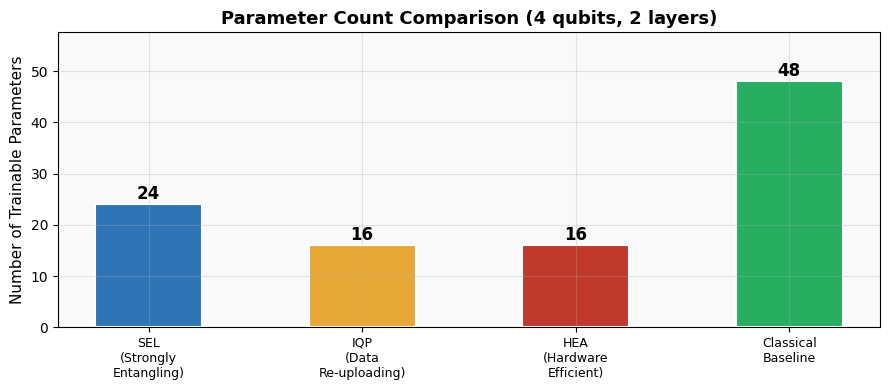


💾 Plot saved as 'param_count_comparison.png'


In [11]:
# ── Parameter Count Comparison ─────────────────────────────────────────────

param_counts = {
    'SEL\n(Strongly\nEntangling)': int(np.prod(sel_weight_shape)),
    'IQP\n(Data\nRe-uploading)': N_LAYERS * N_QUBITS * 2,
    'HEA\n(Hardware\nEfficient)': N_LAYERS * N_QUBITS * 2,
    'Classical\nBaseline': classical_attn.count_parameters()
}

colors = ['#2E75B6', '#E8A838', '#C0392B', '#27AE60']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(param_counts.keys(), param_counts.values(), color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, param_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Trainable Parameters', fontsize=11)
ax.set_title(f'Parameter Count Comparison ({N_QUBITS} qubits, {N_LAYERS} layers)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(param_counts.values()) * 1.2)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('param_count_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Plot saved as 'param_count_comparison.png'")

---

## Cell — Output Distribution Comparison

Run each circuit 200 times with random inputs and random parameters. Plot the distribution of output values (expectation values). This tells us:
- Does the circuit explore the full [-1, 1] output space?
- Or does it concentrate around a narrow range? (bad for attention weights)

In [12]:
# ── Output Distribution Comparison ─────────────────────────────────────────

N_SAMPLES = 200
print(f"Running {N_SAMPLES} random evaluations per circuit...")

def sample_outputs(circuit, weight_shape, n_samples=N_SAMPLES):
    """Run circuit n_samples times with random inputs and weights. Return all outputs."""
    outputs = []
    for _ in range(n_samples):
        inp = torch.tensor(np.random.uniform(0, np.pi, N_QUBITS), dtype=torch.float32)
        w   = torch.tensor(np.random.uniform(0, 2*np.pi, weight_shape), dtype=torch.float32)
        out = circuit(inp, w)
        outputs.extend([float(v) for v in out])
    return outputs

sel_outputs = sample_outputs(sel_circuit, sel_weight_shape)
print("  SEL done ✓")
iqp_outputs = sample_outputs(iqp_circuit, (N_LAYERS, N_QUBITS, 2))
print("  IQP done ✓")
hea_outputs = sample_outputs(hea_circuit, (N_LAYERS, N_QUBITS, 2))
print("  HEA done ✓")
print("All done!")

Running 200 random evaluations per circuit...
  SEL done ✓
  IQP done ✓
  HEA done ✓
All done!


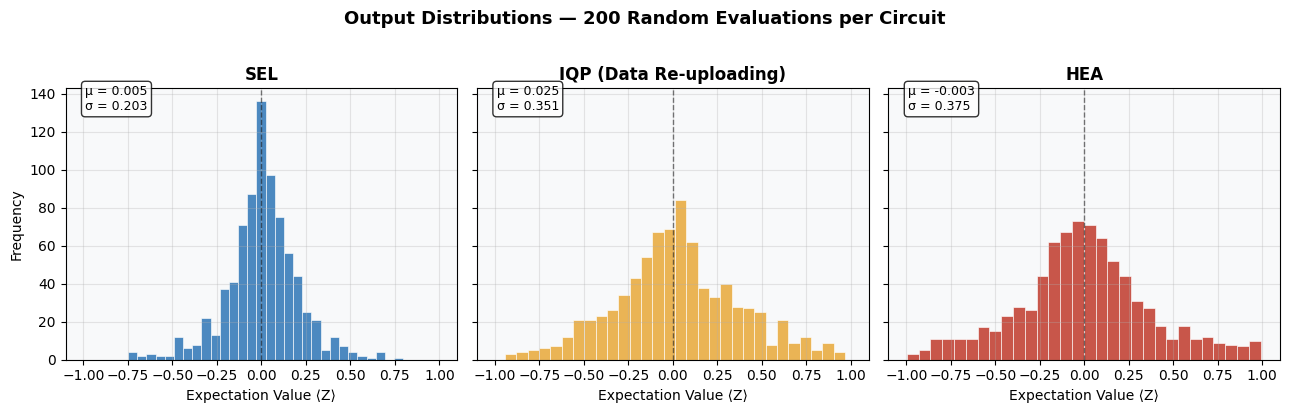

💾 Plot saved as 'output_distributions.png'


In [13]:
# Plot output distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

datasets = [
    (sel_outputs, 'SEL', '#2E75B6'),
    (iqp_outputs, 'IQP (Data Re-uploading)', '#E8A838'),
    (hea_outputs, 'HEA', '#C0392B')
]

for ax, (data, label, color) in zip(axes, datasets):
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Zero')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Expectation Value ⟨Z⟩', fontsize=10)
    ax.set_xlim(-1.1, 1.1)

    # Show mean and std
    mean, std = np.mean(data), np.std(data)
    ax.text(0.05, 0.92, f'μ = {mean:.3f}\nσ = {std:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Frequency', fontsize=10)
fig.suptitle('Output Distributions — 200 Random Evaluations per Circuit',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('output_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Plot saved as 'output_distributions.png'")

---

## Cell — Summary Table

In [14]:
# ── Summary Table ──────────────────────────────────────────────────────────

print("=" * 70)
print(f"{'CIRCUIT SUMMARY':^70}")
print(f"Configuration: {N_QUBITS} qubits, {N_LAYERS} layers")
print("=" * 70)
print(f"{'Circuit':<28} {'Params':>8} {'Output μ':>10} {'Output σ':>10} {'Re-upload':>10}")
print("-" * 70)
print(f"{'SEL (Strongly Entangling)':<28} {np.prod(sel_weight_shape):>8} {np.mean(sel_outputs):>10.4f} {np.std(sel_outputs):>10.4f} {'No':>10}")
print(f"{'IQP (Data Re-uploading)':<28} {N_LAYERS*N_QUBITS*2:>8} {np.mean(iqp_outputs):>10.4f} {np.std(iqp_outputs):>10.4f} {'Yes':>10}")
print(f"{'HEA (Hardware-Efficient)':<28} {N_LAYERS*N_QUBITS*2:>8} {np.mean(hea_outputs):>10.4f} {np.std(hea_outputs):>10.4f} {'No':>10}")
print(f"{'Classical Baseline':<28} {classical_attn.count_parameters():>8} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
print("=" * 70)
print()
print("📌 Interpretation guide:")
print("  σ close to 0  → outputs cluster near one value (low diversity = bad for attention)")
print("  σ close to 0.5→ outputs spread across [-1,1] (high diversity = good)")
print("  μ close to 0  → outputs are balanced around zero (desirable)")
print()
print("➡️  Next: Notebook 02 — Expressibility Analysis")

                           CIRCUIT SUMMARY                            
Configuration: 4 qubits, 2 layers
Circuit                        Params   Output μ   Output σ  Re-upload
----------------------------------------------------------------------
SEL (Strongly Entangling)          24     0.0052     0.2030         No
IQP (Data Re-uploading)            16     0.0251     0.3514        Yes
HEA (Hardware-Efficient)           16    -0.0026     0.3749         No
Classical Baseline                 48        N/A        N/A        N/A

📌 Interpretation guide:
  σ close to 0  → outputs cluster near one value (low diversity = bad for attention)
  σ close to 0.5→ outputs spread across [-1,1] (high diversity = good)
  μ close to 0  → outputs are balanced around zero (desirable)

➡️  Next: Notebook 02 — Expressibility Analysis


---

## Save to Google Drive (Optional but Recommended)

In [15]:
# ── Optional: Save outputs to Google Drive ─────────────────────────────────
# Uncomment and run if you want to save to Drive

from google.colab import drive
drive.mount('/content/drive')

import shutil, os
save_dir = '/content/drive/MyDrive/quantum-attention-benchmark/results/'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('param_count_comparison.png', save_dir)
shutil.copy('output_distributions.png', save_dir)
print(f'✅ Files saved to {save_dir}')

print("Notebook 01 complete! ✅")
print()
print("What you built:")
print("  ✓ Circuit 1: Strongly Entangling Layers (SEL)")
print("  ✓ Circuit 2: IQP with Data Re-uploading")
print("  ✓ Circuit 3: Hardware-Efficient Ansatz (HEA)")
print("  ✓ Classical Attention Baseline")
print("  ✓ Parameter count comparison plot")
print("  ✓ Output distribution comparison plot")
print()
print("Next step: Open 02_expressibility.ipynb")

Mounted at /content/drive
✅ Files saved to /content/drive/MyDrive/quantum-attention-benchmark/results/
Notebook 01 complete! ✅

What you built:
  ✓ Circuit 1: Strongly Entangling Layers (SEL)
  ✓ Circuit 2: IQP with Data Re-uploading
  ✓ Circuit 3: Hardware-Efficient Ansatz (HEA)
  ✓ Classical Attention Baseline
  ✓ Parameter count comparison plot
  ✓ Output distribution comparison plot

Next step: Open 02_expressibility.ipynb
